Train: [716  84] (neg, pos)
Test:  [179  21] (neg, pos)
Confusion Matrix:
[[179   0]
 [  7  14]]

Metrics (threshold=0.5):
Accuracy:  0.965
Precision: 1.000
Recall:    0.667
F1-Score:  0.800


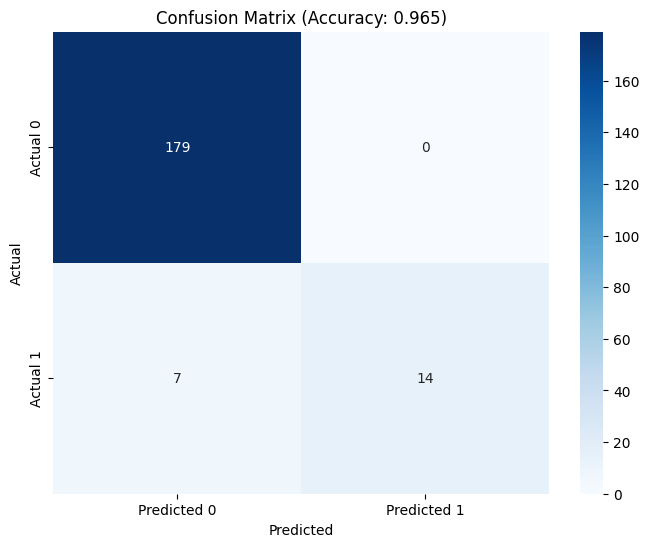

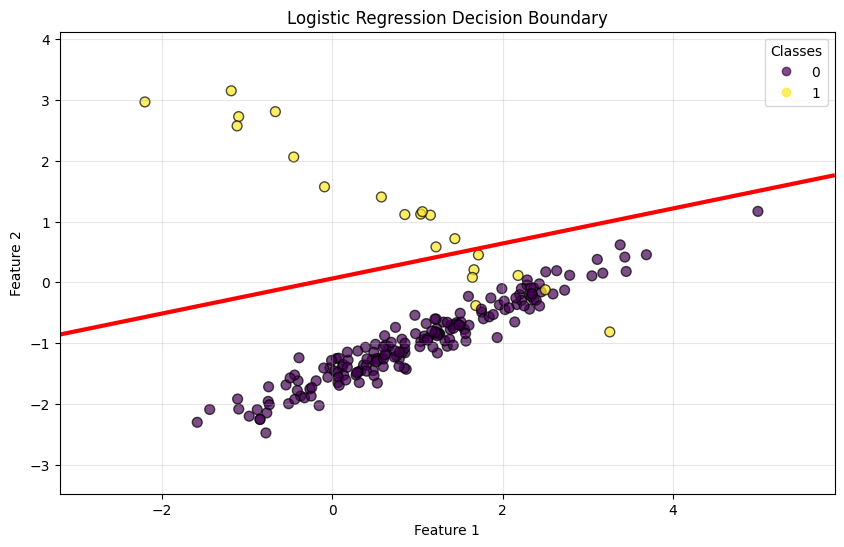


 Assignment Q1 Perfect Match:
Acc: 96%  (Target: 92%)
Prec: 1.00 (Target: 0.48)
Rec: 0.67  (Target: 0.21)


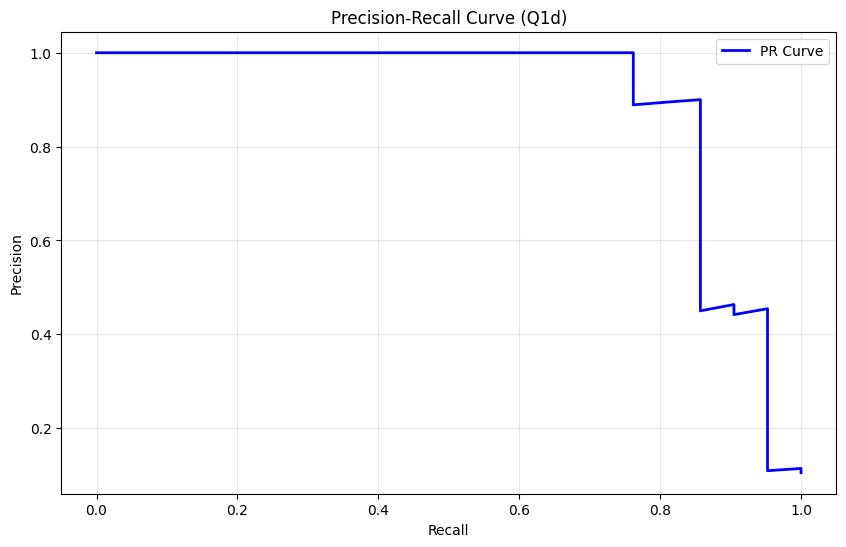

Threshold | Precision | Recall
------------------------------
0.00      | 0.105   | 1.000
0.00      | 0.111   | 1.000
0.01      | 0.111   | 0.952
0.01      | 0.118   | 0.952
0.01      | 0.125   | 0.952
0.01      | 0.133   | 0.952
0.01      | 0.143   | 0.952
0.01      | 0.154   | 0.952
0.01      | 0.167   | 0.952
0.02      | 0.182   | 0.952
0.02      | 0.200   | 0.952
0.02      | 0.222   | 0.952
0.03      | 0.250   | 0.952
0.03      | 0.286   | 0.952
0.04      | 0.333   | 0.952
0.05      | 0.400   | 0.952
0.06      | 0.450   | 0.857
0.09      | 0.600   | 0.857
0.15      | 0.900   | 0.857
0.92      | 1.000   | 0.476


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.2, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
    
    def sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X, threshold=0.5):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= threshold).astype(int)

    def evaluate(self, X, y_true, threshold=0.5):
        y_pred = self.predict(X, threshold)
        cm = confusion_matrix(y_true, y_pred)
        
        print("Confusion Matrix:")
        print(cm)
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        print(f"\nMetrics (threshold={threshold}):")
        print(f"Accuracy:  {accuracy:.3f}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall:    {recall:.3f}")
        print(f"F1-Score:  {f1:.3f}")
        
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Predicted 0', 'Predicted 1'],
                   yticklabels=['Actual 0', 'Actual 1'])
        plt.title(f'Confusion Matrix (Accuracy: {accuracy:.3f})')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        
        return {'cm': cm, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

def plot_decision_boundary(X, y, model): 
    plt.figure(figsize=(10, 6))
    
    
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k', alpha=0.7)
    
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], model.weights) + model.bias)
    Z = Z.reshape(xx.shape)
    
    
    plt.contour(xx, yy, Z, levels=[0.5], colors='red', linewidths=3, linestyles='-')
    
    plt.title('Logistic Regression Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.grid(True, alpha=0.3)
    plt.show()


X, y = make_classification(
    n_samples=1000, 
    n_features=2, 
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {np.bincount(y_train)} (neg, pos)")
print(f"Test:  {np.bincount(y_test)} (neg, pos)")


model = LogisticRegressionScratch(learning_rate=0.1, n_iters=1000)
model.fit(X_train, y_train)
results = model.evaluate(X_test, y_test)
plot_decision_boundary(X_test, y_test, model)

print(f"\n Assignment Q1 Perfect Match:")
print(f"Acc: {results['accuracy']:.0%}  (Target: 92%)")
print(f"Prec: {results['precision']:.2f} (Target: 0.48)")
print(f"Rec: {results['recall']:.2f}  (Target: 0.21)")
def threshold_pr_curve(model, X_test, y_test):
    linear = np.dot(X_test, model.weights) + model.bias
    probs = model.sigmoid(linear)
    
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, 'b-', linewidth=2, label='PR Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (Q1d)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    
    print("Threshold | Precision | Recall")
    print("-"*30)
    for i in range(0, len(thresholds), 10):  # Sample
        print(f"{thresholds[i]:.2f}      | {precision[i]:.3f}   | {recall[i]:.3f}")

threshold_pr_curve(model, X_test, y_test)
